
# CNN Transfer Baseline — DeepFakeDetector

**Goal:** Fine-tune a pretrained CNN to classify images as **Real** vs **AI-generated** (deepfakes).  
This notebook is a **beginner-friendly, end-to-end baseline** that you can run locally or in Colab.

**Backbones supported:** `EfficientNet-B0` (default) and `ResNet-50` (toggle below).  
**Metrics:** Accuracy, F1, AUROC.  
**Extras:** Optional saliency map for interpretability, model checkpointing, and clear instructions.

> ✅ This file is the deliverable requested by the issue: `notebooks/cnn_transfer_baseline.ipynb`.


In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



## 0. Setup

- You need Python 3.10+ recommended.
- If running the notebook locally, install dependencies with the cell below.
- If running in **Google Colab**, the cell will also work; GPU is recommended.

> Dataset (expected folder structure):
```
data/
  train/
    real/
    fake/
  val/
    real/
    fake/
```
- Each folder contains images (JPG/PNG). You may rename `fake` to `ai` if you like—just update the `CLASS_NAMES` below.


In [19]:
!apt-get update -qq
!apt-get install -y -qq unzip
!unzip -q -o /content/datasets.zip -d /content
!find /content/datasets -maxdepth 3 -type d -print

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
unzip:  cannot find or open /content/datasets.zip, /content/datasets.zip.zip or /content/datasets.zip.ZIP.
/content/datasets
/content/datasets/OpenImagesV7
/content/datasets/OpenImagesV7/all_real
/content/datasets/OpenImagesV7/train


In [20]:

# If you are on Colab or a fresh environment, uncomment and run:
# %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
# %pip install scikit-learn matplotlib tqdm pillow captum


In [21]:
# =========================
# CELL 1: Imports + config
# =========================
import os, time, copy, math, random
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Make DEVICE a torch.device (not a string)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# ---- Beginner-friendly switches ----
USE_MODEL = "efficientnet_b0"
FREEZE_BACKBONE = True
UNFREEZE_EPOCH = 3              # set None to keep frozen
NUM_EPOCHS = 10

# You can crank this up later if it fits
BATCH_SIZE = 64

LR = 1e-3
WEIGHT_DECAY = 1e-4

# When using local /content data, 2-4 is good
# If you see stalls, set to 0
NUM_WORKERS = 2

IM_SIZE = 224

Using device: cuda


In [22]:
# =========================
# CELL 2: Reproducibility
# =========================
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Deterministic can reduce speed but improves reproducibility
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("Seed set.")


Seed set.


In [7]:
# =========================================
# Fetch OpenImagesV7 (all REAL) into /content/datasets and build an "all_real" loader
# =========================================

import shutil
from pathlib import Path
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# ---- 1) Fetch using repo script ----
if not Path("DeepFakeDetector").exists():
    !git clone https://github.com/McMasterAI-Society/DeepFakeDetector.git
else:
    %cd DeepFakeDetector
    !git pull
    %cd ..

%cd DeepFakeDetector
!python scripts/fetch_sample_datasets.py --open-images-v7 --max-train 500 --max-test 200

# ---- 2) Copy to your notebook's expected root ----
target_root = Path("/content/datasets")
target_root.mkdir(parents=True, exist_ok=True)

src = Path("datasets/OpenImagesV7")
dst = target_root / "OpenImagesV7"
if dst.exists():
    shutil.rmtree(dst)
shutil.copytree(src, dst)

print("✅ Copied to:", dst)

# ---- 3) Flatten into a single folder (all real) ----
all_real_dir = dst / "all_real"
if all_real_dir.exists():
    shutil.rmtree(all_real_dir)
all_real_dir.mkdir(parents=True, exist_ok=True)

img_exts = {".jpg", ".jpeg", ".png", ".webp"}
n = 0
for p in dst.rglob("*"):
    if p.is_file() and p.suffix.lower() in img_exts:
        # avoid copying duplicates inside all_real if it already lives there
        if all_real_dir in p.parents:
            continue
        shutil.copy2(p, all_real_dir / p.name)
        n += 1

print(f"✅ Flattened into {all_real_dir} with {n} images")

# ---- 4) Build a dataset where every label = 0 (real) ----
IM_SIZE = int(globals().get("IM_SIZE", 224))
BATCH_SIZE = int(globals().get("BATCH_SIZE", 64))
NUM_WORKERS = int(globals().get("NUM_WORKERS", 2))

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

openimages_tfm = transforms.Compose([
    transforms.Resize((IM_SIZE, IM_SIZE)),
    transforms.ToTensor(),
    normalize
])

class AllRealFolder(Dataset):
    def __init__(self, root: Path, transform=None):
        self.root = Path(root)
        self.transform = transform
        self.paths = sorted([p for p in self.root.iterdir() if p.is_file() and p.suffix.lower() in img_exts])
        if len(self.paths) == 0:
            raise FileNotFoundError(f"No images found in {self.root}")

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        p = self.paths[idx]
        img = Image.open(p).convert("RGB")
        if self.transform:
            img = self.transform(img)
        y = 0  # all real
        return img, y

openimages_real_ds = AllRealFolder(all_real_dir, transform=openimages_tfm)
openimages_real_loader = DataLoader(
    openimages_real_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
)

globals()["openimages_real_ds"] = openimages_real_ds
globals()["openimages_real_loader"] = openimages_real_loader

print("✅ openimages_real_loader ready:", len(openimages_real_ds), "images")
%cd ..

Cloning into 'DeepFakeDetector'...
remote: Enumerating objects: 649, done.
remote: Counting objects: 100% (423/423), done.
remote: Compressing objects: 100% (276/276), done.
remote: Total 649 (delta 196), reused 303 (delta 137), pack-reused 226 (from 1)
Receiving objects: 100% (649/649), 9.72 MiB | 13.07 MiB/s, done.
Resolving deltas: 100% (261/261), done.
/content/DeepFakeDetector/DeepFakeDetector
README.md: 2.81kB [00:00, 7.54MB/s]
data/train-00000-of-00002.parquet: 100% 180M/180M [00:03<00:00, 48.8MB/s]
data/train-00001-of-00002.parquet: 100% 180M/180M [00:04<00:00, 39.1MB/s]
data/test-00000-of-00001.parquet: 100% 4.99M/4.99M [00:01<00:00, 4.05MB/s]
data/validation-00000-of-00001.parquet: 100% 1.66M/1.66M [00:00<00:00, 3.02MB/s]
Generating train split: 100% 9011219/9011219 [00:06<00:00, 1315560.75 examples/s]
Generating test split: 100% 125436/125436 [00:00<00:00, 1372712.35 examples/s]
Generating validation split: 100% 41620/41620 [00:00<00:00, 1825231.15 examples/s]
[HF] bitmind/o


## 1. Data Loading and Augmentations

- We use `ImageFolder` so the folder names define classes.
- Basic augmentations help generalization.


In [23]:
# ==========================================
# CELL: Combined training on OpenFake + DRAGON + wildfake_2k_split (train + test)
# Updates for Issue #46:
# - Stronger augmentations (RandomResizedCrop, small rotation, blur, random erasing, optional JPEG compression)
# - Class distribution print
# - Optional WeightedRandomSampler + optional class-weighted loss support
# ==========================================

from pathlib import Path
import shutil
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset, Dataset, WeightedRandomSampler
from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

# -------- Settings --------
IM_SIZE = int(globals().get("IM_SIZE", 224))
BATCH_SIZE = int(globals().get("BATCH_SIZE", 64))
NUM_WORKERS = int(globals().get("NUM_WORKERS", 2))
PIN_MEMORY = True

# Sampler behavior
USE_WEIGHTED_SAMPLER = bool(globals().get("USE_WEIGHTED_SAMPLER", True))
IMBALANCE_RATIO_THRESHOLD = float(globals().get("IMBALANCE_RATIO_THRESHOLD", 1.25))  # enable sampler if max/min >= this

# Optional: also use class-weighted loss (usually use either sampler OR weights)
USE_CLASS_WEIGHTED_LOSS = bool(globals().get("USE_CLASS_WEIGHTED_LOSS", False))

# Optional: JPEG compression simulation
USE_JPEG_SIM = bool(globals().get("USE_JPEG_SIM", True))

# -------- Ensure Drive mounted --------
if not Path("/content/drive").exists():
    from google.colab import drive
    drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive/datasets")

DATASETS = {
    "OpenFake": DRIVE_ROOT / "OpenFake",
    "DRAGON": DRIVE_ROOT / "DRAGON",
    "wildfake_2k_split": DRIVE_ROOT / "wildfake_2k_split",
}

TRAIN_NAMES = ["train", "Train", "training"]
TEST_NAMES  = ["test", "Test", "val", "Val", "valid", "validation"]

def find_split(base: Path, split_names):
    for n in split_names:
        p = base / n
        if p.exists() and p.is_dir():
            return p
    for child in base.iterdir():
        if child.is_dir():
            for n in split_names:
                p = child / n
                if p.exists() and p.is_dir():
                    return p
    return None

# -------- Optional Albumentations JPEG transform (PIL in, PIL out) --------
class OptionalJPEGCompression:
    def __init__(self, enabled: bool = True, quality_lower: int = 55, quality_upper: int = 95, p: float = 0.35):
        self.enabled = enabled
        self.p = p
        self._ok = False
        self._aug = None

        if not enabled:
            return

        try:
            import albumentations as A
            self._aug = A.Compose([
                A.ImageCompression(quality_lower=quality_lower, quality_upper=quality_upper, p=p)
            ])
            self._ok = True
        except Exception:
            # Albumentations not installed or not available
            self._ok = False

    def __call__(self, img: Image.Image) -> Image.Image:
        if not (self.enabled and self._ok):
            return img
        import numpy as _np
        arr = _np.array(img)
        out = self._aug(image=arr)["image"]
        return Image.fromarray(out)

jpeg_sim = OptionalJPEGCompression(enabled=USE_JPEG_SIM)

# -------- Transforms --------
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

train_tfm = transforms.Compose([
    transforms.Lambda(lambda im: jpeg_sim(im)),  # optional JPEG compression simulation
    transforms.RandomResizedCrop(IM_SIZE, scale=(0.80, 1.00), ratio=(0.90, 1.10)),
    transforms.RandomRotation(10),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))], p=0.20),
    transforms.ToTensor(),
    normalize,
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.12), ratio=(0.3, 3.3), value="random"),
])

test_tfm = transforms.Compose([
    transforms.Resize((IM_SIZE, IM_SIZE)),
    transforms.ToTensor(),
    normalize,
])

globals()["train_tfm"] = train_tfm
globals()["val_tfm"] = test_tfm   # training cell expects val_tfm
globals()["val_tfms"] = test_tfm  # later "reload test" cell tries val_tfms

# -------- Label remap wrapper: enforce 0=real, 1=fake --------
class RemapLabels(Dataset):
    def __init__(self, base_ds, class_to_idx):
        self.base_ds = base_ds
        if "real" not in class_to_idx or "fake" not in class_to_idx:
            raise RuntimeError(f"Expected 'real' and 'fake' classes, got {class_to_idx}")
        self.map = {
            class_to_idx["real"]: 0,
            class_to_idx["fake"]: 1
        }

    def __len__(self):
        return len(self.base_ds)

    def __getitem__(self, idx):
        x, y = self.base_ds[idx]
        return x, self.map[int(y)]

def wrap_imagefolder_with_remap(ds: datasets.ImageFolder):
    return RemapLabels(ds, ds.class_to_idx)

train_parts = []
val_parts = []

# We will also track per-sample labels so we can build a WeightedRandomSampler across ConcatDataset
train_labels_all = []

print("\n=== Dataset discovery and local copy ===")
for name, base_drive in DATASETS.items():
    if not base_drive.exists():
        raise FileNotFoundError(f"Missing dataset folder on Drive: {base_drive}")

    train_drive = find_split(base_drive, TRAIN_NAMES)
    test_drive  = find_split(base_drive, TEST_NAMES)

    print(f"\n{name} base:", base_drive)
    print(f"{name} train:", train_drive)
    print(f"{name} test :", test_drive)

    if train_drive is None or test_drive is None:
        print(f"{name}: could not find train/test. Listing one level under base:")
        for p in sorted(base_drive.iterdir()):
            if p.is_dir():
                print(" -", p)
        raise FileNotFoundError(f"{name}: train/test split folders not found under {base_drive}")

    local_root = Path("/content") / f"dataset_local_{name}"
    train_local = local_root / "train"
    test_local  = local_root / "test"

    if not train_local.exists() or not test_local.exists():
        print(f"{name}: copying to local disk for speed...")
        if local_root.exists():
            shutil.rmtree(local_root)
        local_root.mkdir(parents=True, exist_ok=True)
        shutil.copytree(train_drive, train_local)
        shutil.copytree(test_drive,  test_local)
        print(f"{name}: copy complete -> {local_root}")
    else:
        print(f"{name}: local copy exists -> {local_root}")

    ds_tr_raw = datasets.ImageFolder(str(train_local), transform=train_tfm)
    ds_te_raw = datasets.ImageFolder(str(test_local),  transform=test_tfm)

    print(f"{name}: raw classes={ds_tr_raw.classes} raw class_to_idx={ds_tr_raw.class_to_idx}")
    print(f"{name}: train={len(ds_tr_raw)} test={len(ds_te_raw)}")

    # Record mapped labels for imbalance inspection and optional sampler
    mapped_train = [0 if ds_tr_raw.classes[y] == "real" else 1 for y in ds_tr_raw.targets] if False else None
    # Safer: use class_to_idx mapping instead of ds_tr_raw.classes indexing
    c2i = ds_tr_raw.class_to_idx
    mapped_train = [0 if int(t) == c2i["real"] else 1 for t in ds_tr_raw.targets]
    train_labels_all.extend(mapped_train)

    # Wrap to enforce: 0=real, 1=fake no matter what ImageFolder picked
    ds_tr = wrap_imagefolder_with_remap(ds_tr_raw)
    ds_te = wrap_imagefolder_with_remap(ds_te_raw)

    train_parts.append(ds_tr)
    val_parts.append(ds_te)

# -------- Combined datasets --------
train_ds = ConcatDataset(train_parts)
val_ds   = ConcatDataset(val_parts)

globals()["train_ds"] = train_ds
globals()["val_ds"] = val_ds

# -------- Class distribution check --------
train_labels_all = np.array(train_labels_all, dtype=int)
count_real = int((train_labels_all == 0).sum())
count_fake = int((train_labels_all == 1).sum())
print("\n=== Train label distribution (0=real, 1=fake) ===")
print("real:", count_real)
print("fake:", count_fake)

min_c = max(1, min(count_real, count_fake))
max_c = max(count_real, count_fake)
imbalance_ratio = max_c / min_c
print("imbalance ratio (max/min):", float(imbalance_ratio))

# Build optional sampler + optional class weights
sampler = None
class_weights = None

if USE_WEIGHTED_SAMPLER and imbalance_ratio >= IMBALANCE_RATIO_THRESHOLD:
    # Inverse frequency weights per class
    w_real = 1.0 / max(1, count_real)
    w_fake = 1.0 / max(1, count_fake)
    sample_weights = np.where(train_labels_all == 0, w_real, w_fake).astype(np.float64).tolist()

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
    print("✅ Using WeightedRandomSampler for training loader (imbalanced classes).")

if USE_CLASS_WEIGHTED_LOSS and (count_real > 0 and count_fake > 0):
    # Normalize weights roughly, bigger weight for minority class
    total = count_real + count_fake
    class_weights = torch.tensor(
        [total / (2.0 * max(1, count_real)), total / (2.0 * max(1, count_fake))],
        dtype=torch.float32
    )
    print("✅ Using class-weighted loss weights:", class_weights.tolist())

globals()["CLASS_WEIGHTS"] = class_weights  # used in loss cell if enabled
globals()["TRAIN_SAMPLER"] = sampler

# -------- Loaders --------
if sampler is not None:
    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        sampler=sampler,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )
else:
    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0),
)

globals()["train_loader"] = train_loader
globals()["val_loader"] = val_loader

print("\n✅ Combined dataset ready (consistent labels: 0=real, 1=fake)")
print("batch_size:", BATCH_SIZE, "num_workers:", NUM_WORKERS)
print("train size:", len(train_ds), "test-as-val size:", len(val_ds))
print("batches/epoch:", len(train_loader))

xb, yb = next(iter(train_loader))
print("one batch:", tuple(xb.shape), "label values:", sorted(set(yb.tolist())))


=== Dataset discovery and local copy ===

OpenFake base: /content/drive/MyDrive/datasets/OpenFake
OpenFake train: /content/drive/MyDrive/datasets/OpenFake/train
OpenFake test : /content/drive/MyDrive/datasets/OpenFake/test
OpenFake: local copy exists -> /content/dataset_local_OpenFake
OpenFake: raw classes=['fake', 'real'] raw class_to_idx={'fake': 0, 'real': 1}
OpenFake: train=8987 test=1000

DRAGON base: /content/drive/MyDrive/datasets/DRAGON
DRAGON train: /content/drive/MyDrive/datasets/DRAGON/train
DRAGON test : /content/drive/MyDrive/datasets/DRAGON/test
DRAGON: local copy exists -> /content/dataset_local_DRAGON
DRAGON: raw classes=['fake', 'real'] raw class_to_idx={'fake': 0, 'real': 1}
DRAGON: train=959 test=188

wildfake_2k_split base: /content/drive/MyDrive/datasets/wildfake_2k_split
wildfake_2k_split train: /content/drive/MyDrive/datasets/wildfake_2k_split/train
wildfake_2k_split test : /content/drive/MyDrive/datasets/wildfake_2k_split/test
wildfake_2k_split: local copy exis

/tmp/ipython-input-2810131834.py:77: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=quality_lower, quality_upper=quality_upper, p=p)


one batch: (64, 3, 224, 224) label values: [0, 1]


In [24]:
# =========================
# ONE-CELL: Colab manual-gen dataset setup (HF -> /content/manual_gen_images)
# Safer: uses Colab Secrets env var HF_TOKEN, no interactive login()
# =========================

!pip -q install -U huggingface_hub datasets

from pathlib import Path
import os
import shutil
from huggingface_hub import snapshot_download
from huggingface_hub.utils import RepositoryNotFoundError, HfHubHTTPError

DATASET_REPO = "DeepFakeDetector/manual-gen-images"

# 1) Read token safely from environment (Colab Secrets)
from google.colab import userdata

token = (userdata.get("HF_TOKEN") or "").strip()
if not token:
    raise RuntimeError("HF_TOKEN secret not found. In Colab Secrets, name must be exactly HF_TOKEN and Notebook access must be enabled.")

# optional: export to env so the rest of your code can use os.environ["HF_TOKEN"]
os.environ["HF_TOKEN"] = token
# 2) Download dataset snapshot (raw repo files)
try:
    local_snapshot = Path(
        snapshot_download(
            repo_id=DATASET_REPO,
            repo_type="dataset",
            token=token,
        )
    )
except RepositoryNotFoundError as e:
    raise RuntimeError(
        f"Repo not found: {DATASET_REPO}. Check spelling and that it is a dataset repo."
    ) from e
except HfHubHTTPError as e:
    # Common: 401 if private/gated or no access
    raise RuntimeError(
        f"HF download failed. If you see 401, you are not authenticated or you do not have access "
        f"to {DATASET_REPO}. Make sure your token is valid and you have permission."
    ) from e

print("Downloaded HF dataset snapshot to:", local_snapshot)

# 3) Build a clean output directory
OUT_ROOT = Path("/content/manual_gen_images")
OUT_IMAGES = OUT_ROOT / "images"
OUT_IMAGES.mkdir(parents=True, exist_ok=True)

# 4) Copy images into /content/manual_gen_images/images/<generator>/
IMG_EXTS = {".png", ".jpg", ".jpeg", ".webp"}

def norm(s: str) -> str:
    return s.lower().replace(" ", "").replace("-", "_")

def guess_gen(path: Path) -> str:
    parts = [norm(p) for p in path.parts]
    if "nanobanana" in parts or "nano_banana" in parts:
        return "nanobanana"
    if "dalle" in parts or "dall_e" in parts or "dall-e" in parts:
        return "dalle"
    if "bing" in parts:
        return "bing"
    parent = norm(path.parent.name)
    if "nano" in parent:
        return "nanobanana"
    if "dall" in parent:
        return "dalle"
    if "bing" in parent:
        return "bing"
    return "unknown"

copied = 0
per_gen = {}

for img_path in local_snapshot.rglob("*"):
    if img_path.is_file() and img_path.suffix.lower() in IMG_EXTS:
        gen = guess_gen(img_path)
        dest_dir = OUT_IMAGES / gen
        dest_dir.mkdir(parents=True, exist_ok=True)

        dest = dest_dir / img_path.name
        if dest.exists():
            dest = dest_dir / f"{img_path.stem}_{copied}{img_path.suffix}"

        shutil.copy2(img_path, dest)
        copied += 1
        per_gen[gen] = per_gen.get(gen, 0) + 1

print("\n✅ Manual-gen images ready at:", OUT_IMAGES)
print("Counts by generator:", dict(sorted(per_gen.items(), key=lambda x: x[0])))
for g in sorted(per_gen):
    print(" -", OUT_IMAGES / g)

Fetching 331 files:   0%|          | 0/331 [00:00<?, ?it/s]

Downloaded HF dataset snapshot to: /root/.cache/huggingface/hub/datasets--DeepFakeDetector--manual-gen-images/snapshots/7d96c89dacfbba469ccd9bddbd1a486cff72b3a1

✅ Manual-gen images ready at: /content/manual_gen_images/images
Counts by generator: {'bing': 27, 'dalle': 100, 'nanobanana': 100}
 - /content/manual_gen_images/images/bing
 - /content/manual_gen_images/images/dalle
 - /content/manual_gen_images/images/nanobanana



## 2. Build the Model (Transfer Learning)

Pick a pretrained backbone and replace the classification head with a 2‑class head.


In [27]:
# =========================
# CELL 4: Model, loss, optimizer (adds optional dropout + optional class-weighted loss)
# =========================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# Ensure DEVICE is torch.device
if "DEVICE" in globals() and isinstance(DEVICE, str):
    DEVICE = torch.device(DEVICE)
elif "DEVICE" not in globals() or not isinstance(DEVICE, torch.device):
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Build model inline (replaces build_model(...)) ----
# Expected: USE_MODEL = "efficientnet_b0"
use_model = str(globals().get("USE_MODEL", "efficientnet_b0")).lower()
if use_model not in ["efficientnet_b0", "effnet_b0", "efficientnet"]:
    raise ValueError(f"This cell only supports EfficientNet-B0. Got USE_MODEL={use_model}")

weights = models.EfficientNet_B0_Weights.DEFAULT
model = models.efficientnet_b0(weights=weights)

# Replace final classifier to 2 classes
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 2)

# Freeze backbone if requested
FREEZE_BACKBONE = bool(globals().get("FREEZE_BACKBONE", True))
if FREEZE_BACKBONE:
    for p in model.features.parameters():
        p.requires_grad = False
    for p in model.classifier.parameters():
        p.requires_grad = True

model = model.to(DEVICE)

# Optional: add extra dropout before final classifier (safe, only if we can find a last Linear)
EXTRA_DROPOUT_P = float(globals().get("EXTRA_DROPOUT_P", 0.20))

def _inject_dropout_before_last_linear(module: nn.Module, p: float) -> bool:
    # Look for common classifier containers
    for attr in ["classifier", "fc", "head"]:
        if hasattr(module, attr):
            sub = getattr(module, attr)
            if isinstance(sub, nn.Sequential):
                layers = list(sub.children())
                # If Sequential already has a Dropout right before a Linear, do nothing
                for i in range(len(layers) - 1):
                    if isinstance(layers[i], nn.Dropout) and isinstance(layers[i + 1], nn.Linear):
                        return False
                # Insert Dropout before the last Linear if present
                for j in range(len(layers) - 1, -1, -1):
                    if isinstance(layers[j], nn.Linear):
                        layers.insert(j, nn.Dropout(p=p))
                        setattr(module, attr, nn.Sequential(*layers))
                        return True
            elif isinstance(sub, nn.Linear):
                # Replace Linear with Dropout + Linear
                setattr(module, attr, nn.Sequential(nn.Dropout(p=p), sub))
                return True
    return False

did_drop = _inject_dropout_before_last_linear(model, EXTRA_DROPOUT_P)
print("extra dropout injected:", did_drop)

# Loss: label smoothing + optional class weights from data cell
class_weights = globals().get("CLASS_WEIGHTS", None)
if class_weights is not None:
    class_weights = class_weights.to(DEVICE)

criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1,
    weight=class_weights
)

def _make_optimizer_for_trainable_params(m, lr, wd):
    trainable_params = [p for p in m.parameters() if p.requires_grad]
    print("trainable param tensors:", len(trainable_params))
    if len(trainable_params) == 0:
        raise RuntimeError(
            "No trainable parameters. Your model is fully frozen. "
            "Set FREEZE_BACKBONE=False, or ensure the classifier head is unfrozen."
        )
    return optim.AdamW(trainable_params, lr=lr, weight_decay=wd)

optimizer = _make_optimizer_for_trainable_params(model, LR, WEIGHT_DECAY)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Model: {use_model} | Trainable params: {trainable:,} / {total:,} | device: {next(model.parameters()).device}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth




  0%|          | 0.00/20.5M [00:00<?, ?B/s]

 20%|█▉        | 4.00M/20.5M [00:00<00:00, 41.5MB/s]

100%|██████████| 20.5M/20.5M [00:00<00:00, 79.3MB/s]


extra dropout injected: False
trainable param tensors: 2
Model: efficientnet_b0 | Trainable params: 2,562 / 4,010,110 | device: cuda:0



## 3. Training & Validation Loop

- Trains with the head (and optionally unfreezes the backbone later).
- Tracks Accuracy, F1, and AUROC.
- Saves the **best** model checkpoint by AUROC.


In [28]:
# =========================
# CELL 3: Train loop with warmup + cosine + early stopping on val AUROC
# Updates for Issue #46:
# - Explicit warmup (1 to 2 epochs worth of steps)
# - CosineAnnealing scheduler after warmup
# - Re-warmup after unfreeze (short warmup recommended)
# - Early stopping remains on val AUROC (patience=3)
# =========================

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import math, time
from pathlib import Path
import numpy as np
import torch
import torch.optim as optim

# --------- Drive run directory setup ----------
DRIVE_BASE = Path("/content/drive/MyDrive/DeepFakeDetector_runs")
RUN_NAME = time.strftime("cnn_transfer_%Y%m%d_%H%M%S")
DRIVE_RUN_DIR = DRIVE_BASE / RUN_NAME
DRIVE_RUN_DIR.mkdir(parents=True, exist_ok=True)

DRIVE_CKPT_DIR = DRIVE_RUN_DIR / "checkpoints"
DRIVE_CKPT_DIR.mkdir(parents=True, exist_ok=True)

DRIVE_ARTIFACTS_DIR = DRIVE_RUN_DIR / "artifacts"
DRIVE_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("Drive run dir:", DRIVE_RUN_DIR)

# Local artifacts (still useful for downstream cells)
ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

best_path = DRIVE_CKPT_DIR / f"best_{USE_MODEL}.pt"

FAKE_IDX = 1  # fixed convention: 0 real, 1 fake

HEARTBEAT_EVERY = 50
SMI_EVERY = 200  # set 0 to disable

# Ensure DEVICE is torch.device
if "DEVICE" in globals() and isinstance(DEVICE, str):
    DEVICE = torch.device(DEVICE)
elif "DEVICE" not in globals() or not isinstance(DEVICE, torch.device):
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(DEVICE)

if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True

use_amp = (DEVICE.type == "cuda")
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

def _rebuild_optimizer_trainable(lr):
    global optimizer
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    print("trainable param tensors (optimizer rebuild):", len(trainable_params))
    if len(trainable_params) == 0:
        raise RuntimeError("Optimizer rebuild found 0 trainable params. Model is still frozen.")
    optimizer = optim.AdamW(trainable_params, lr=lr, weight_decay=WEIGHT_DECAY)

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    probs_all, y_all = [], []
    running_loss = 0.0

    ctx = torch.enable_grad() if is_train else torch.inference_mode()
    with ctx:
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            if use_amp:
                with torch.amp.autocast("cuda", enabled=True):
                    logits = model(imgs)
                    loss = criterion(logits, labels)
            else:
                logits = model(imgs)
                loss = criterion(logits, labels)

            if is_train:
                if use_amp:
                    scaler.scale(loss).backward()

                    has_any_grad = any(
                        (p.grad is not None)
                        for group in optimizer.param_groups
                        for p in group["params"]
                    )
                    if not has_any_grad:
                        raise RuntimeError(
                            "No gradients found during AMP step. "
                            "Your optimizer likely has 0 trainable params or model is fully frozen."
                        )

                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()

                    has_any_grad = any(
                        (p.grad is not None)
                        for group in optimizer.param_groups
                        for p in group["params"]
                    )
                    if not has_any_grad:
                        raise RuntimeError(
                            "No gradients found. Your optimizer likely has 0 trainable params or model is fully frozen."
                        )

                    optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            probs_fake = torch.softmax(logits.detach(), dim=1)[:, FAKE_IDX]
            probs_all.append(probs_fake.float().cpu().numpy())
            y_all.append(labels.detach().cpu().numpy())

    y_prob = np.concatenate(probs_all) if probs_all else np.array([])
    y_true = np.concatenate(y_all) if y_all else np.array([])

    y_pred = (y_prob >= 0.5).astype(int) if y_prob.size else np.array([])
    epoch_loss = running_loss / max(1, len(loader.dataset))

    acc = accuracy_score(y_true, y_pred) if y_true.size else float("nan")
    f1  = f1_score(y_true, y_pred, zero_division=0) if y_true.size else float("nan")
    try:
        auroc = roc_auc_score(y_true, y_prob) if y_true.size else float("nan")
    except ValueError:
        auroc = float("nan")

    return epoch_loss, acc, f1, auroc

# -------- Scheduler: warmup + cosine --------
steps_per_epoch = len(train_loader)

WARMUP_EPOCHS = int(globals().get("WARMUP_EPOCHS", 2))  # issue suggests 1 to 2 epochs
WARMUP_EPOCHS = max(0, min(WARMUP_EPOCHS, NUM_EPOCHS))

def _make_warmup_cosine(optimizer, total_epochs, steps_per_epoch, warmup_epochs, min_lr_ratio=0.05):
    total_steps = max(1, total_epochs * steps_per_epoch)
    warmup_steps = max(0, warmup_epochs * steps_per_epoch)

    # If warmup is 0, pure cosine
    if warmup_steps == 0:
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps, eta_min=LR * min_lr_ratio)

    # Use SequentialLR if available (Torch >= 1.11 usually)
    try:
        warmup = optim.lr_scheduler.LinearLR(
            optimizer,
            start_factor=0.1,
            end_factor=1.0,
            total_iters=warmup_steps
        )
        cosine = optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=max(1, total_steps - warmup_steps),
            eta_min=LR * min_lr_ratio
        )
        sched = optim.lr_scheduler.SequentialLR(
            optimizer,
            schedulers=[warmup, cosine],
            milestones=[warmup_steps]
        )
        return sched
    except Exception:
        # Fallback: simple LambdaLR warmup then cosine by manual switch
        def lr_lambda(step):
            if step < warmup_steps:
                return 0.1 + 0.9 * (step / max(1, warmup_steps))
            # After warmup: keep at 1.0, cosine handled separately not available in fallback
            return 1.0
        return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

scheduler = _make_warmup_cosine(
    optimizer=optimizer,
    total_epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    warmup_epochs=WARMUP_EPOCHS
)

best_auroc = -1.0
history = {"train": [], "val": []}
PATIENCE = 3
pat = 0

print(f"Training {USE_MODEL} for up to {NUM_EPOCHS} epochs | warmup_epochs={WARMUP_EPOCHS} | patience={PATIENCE}")
print("cuda available:", torch.cuda.is_available())
print("model device:", next(model.parameters()).device)
print("batches per epoch:", len(train_loader))

global_step = 0

for epoch in range(1, NUM_EPOCHS + 1):
    # Optional unfreeze
    if UNFREEZE_EPOCH is not None and epoch == UNFREEZE_EPOCH:
        print(f"Unfreezing backbone at epoch {epoch} and rebuilding optimizer + scheduler with warmup...")

        backbone = None
        for attr in ["features", "backbone", "encoder"]:
            if hasattr(model, attr):
                backbone = getattr(model, attr)
                break

        if backbone is not None:
            for p in backbone.parameters():
                p.requires_grad = True
        else:
            for p in model.parameters():
                p.requires_grad = True

        # smaller LR right after unfreeze is usually more stable
        _rebuild_optimizer_trainable(lr=LR / 10.0)

        remaining_epochs = (NUM_EPOCHS - epoch + 1)
        rewarm = int(globals().get("UNFREEZE_WARMUP_EPOCHS", 1))
        rewarm = max(0, min(rewarm, remaining_epochs))

        scheduler = _make_warmup_cosine(
            optimizer=optimizer,
            total_epochs=remaining_epochs,
            steps_per_epoch=steps_per_epoch,
            warmup_epochs=rewarm
        )

        global_step = 0  # reset step count for the new schedule

    t0 = time.time()
    model.train(True)

    running_loss = 0.0
    probs_all, y_all = [], []

    for step, (imgs, labels) in enumerate(train_loader, start=1):
        imgs = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        if epoch == 1 and step == 1:
            print("first batch:", tuple(imgs.shape), imgs.device, imgs.dtype)

        optimizer.zero_grad(set_to_none=True)

        if use_amp:
            with torch.amp.autocast("cuda", enabled=True):
                logits = model(imgs)
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()

            has_any_grad = any(
                (p.grad is not None)
                for group in optimizer.param_groups
                for p in group["params"]
            )
            if not has_any_grad:
                raise RuntimeError(
                    "No gradients found during AMP step. "
                    "Your optimizer likely has 0 trainable params or model is fully frozen."
                )

            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(imgs)
            loss = criterion(logits, labels)
            loss.backward()

            has_any_grad = any(
                (p.grad is not None)
                for group in optimizer.param_groups
                for p in group["params"]
            )
            if not has_any_grad:
                raise RuntimeError(
                    "No gradients found. Your optimizer likely has 0 trainable params or model is fully frozen."
                )

            optimizer.step()

        # Step scheduler per batch (works for SequentialLR + CosineAnnealingLR)
        try:
            scheduler.step()
        except Exception:
            pass

        global_step += 1

        if HEARTBEAT_EVERY and step % HEARTBEAT_EVERY == 0:
            print(f"epoch {epoch} step {step}/{len(train_loader)} loss {loss.item():.4f}")

        if SMI_EVERY and DEVICE.type == "cuda" and step % SMI_EVERY == 0:
            import subprocess
            out = subprocess.check_output([
                "nvidia-smi",
                "--query-gpu=utilization.gpu,memory.used,memory.total",
                "--format=csv,noheader,nounits"
            ]).decode().strip()
            print("gpu util %, mem used/total MiB:", out)

        running_loss += loss.item() * imgs.size(0)
        probs_fake = torch.softmax(logits.detach(), dim=1)[:, FAKE_IDX]
        probs_all.append(probs_fake.float().cpu().numpy())
        y_all.append(labels.detach().cpu().numpy())

    tr_loss = running_loss / max(1, len(train_loader.dataset))
    y_prob_tr = np.concatenate(probs_all) if probs_all else np.array([])
    y_true_tr = np.concatenate(y_all) if y_all else np.array([])
    tr_pred = (y_prob_tr >= 0.5).astype(int) if y_prob_tr.size else np.array([])

    tr_acc = accuracy_score(y_true_tr, tr_pred) if y_true_tr.size else float("nan")
    tr_f1  = f1_score(y_true_tr, tr_pred, zero_division=0) if y_true_tr.size else float("nan")
    try:
        tr_auc = roc_auc_score(y_true_tr, y_prob_tr) if y_true_tr.size else float("nan")
    except ValueError:
        tr_auc = float("nan")

    va_loss, va_acc, va_f1, va_auc = run_epoch(model, val_loader, optimizer=None)

    dt = time.time() - t0
    history["train"].append((tr_loss, tr_acc, tr_f1, tr_auc))
    history["val"].append((va_loss, va_acc, va_f1, va_auc))

    print(f"Epoch {epoch:02d} | {dt:.1f}s "
          f"| train loss {tr_loss:.4f} acc {tr_acc:.3f} f1 {tr_f1:.3f} auroc {tr_auc:.3f} "
          f"| val loss {va_loss:.4f} acc {va_acc:.3f} f1 {va_f1:.3f} auroc {va_auc:.3f}")

    if not math.isnan(va_auc) and va_auc > best_auroc:
        best_auroc = va_auc
        pat = 0

        torch.save({
            "model_state": model.state_dict(),
            "arch": USE_MODEL,
            "im_size": IM_SIZE,
            "label_map": {"0": "real", "1": "fake"},
            "threshold_default": 0.5,
            "best_val_auroc": float(best_auroc)
        }, best_path)

        local_best = ARTIFACTS_DIR / f"best_{USE_MODEL}.pt"
        try:
            import shutil
            shutil.copy2(best_path, local_best)
        except Exception as e:
            print("Warning: could not copy best ckpt to local artifacts:", e)

        print(f"Saved new best checkpoint (val AUROC={best_auroc:.3f}) -> {best_path}")
    else:
        pat += 1
        print(f"No AUROC improvement. Patience {pat}/{PATIENCE}")
        if pat >= PATIENCE:
            print("Early stopping triggered.")
            break

Drive run dir: /content/drive/MyDrive/DeepFakeDetector_runs/cnn_transfer_20260223_151307
Training efficientnet_b0 for up to 10 epochs | warmup_epochs=2 | patience=3
cuda available: True
model device: cuda:0
batches per epoch: 181
first batch: (64, 3, 224, 224) cuda:0 torch.float32
epoch 1 step 50/181 loss 0.6704
epoch 1 step 100/181 loss 0.6254
epoch 1 step 150/181 loss 0.6310
Epoch 01 | 193.1s | train loss 0.6502 acc 0.635 f1 0.662 auroc 0.685 | val loss 0.5848 acc 0.743 f1 0.789 auroc 0.798
Saved new best checkpoint (val AUROC=0.798) -> /content/drive/MyDrive/DeepFakeDetector_runs/cnn_transfer_20260223_151307/checkpoints/best_efficientnet_b0.pt
epoch 2 step 50/181 loss 0.5383
epoch 2 step 100/181 loss 0.6247
epoch 2 step 150/181 loss 0.5835
Epoch 02 | 162.9s | train loss 0.5764 acc 0.730 f1 0.751 auroc 0.801 | val loss 0.5519 acc 0.759 f1 0.805 auroc 0.823
Saved new best checkpoint (val AUROC=0.823) -> /content/drive/MyDrive/DeepFakeDetector_runs/cnn_transfer_20260223_151307/checkpoi

In [ ]:
!nvidia-smi


## 4. Curves


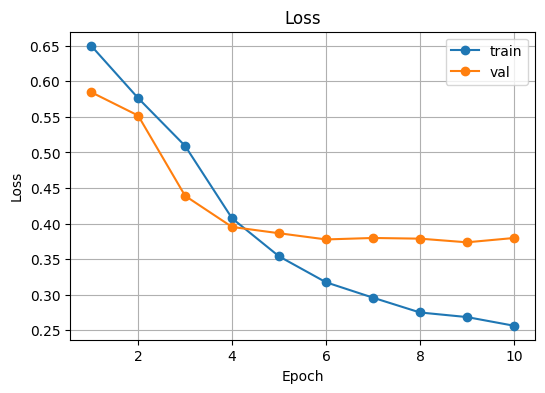

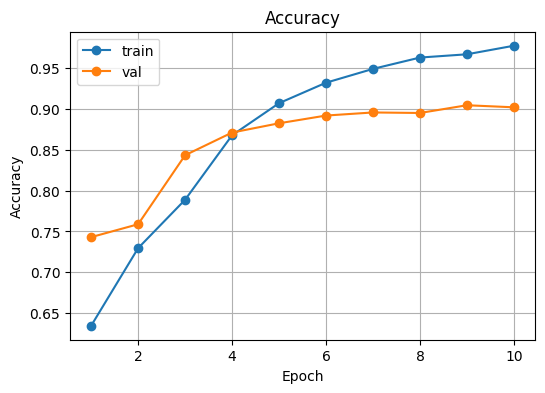

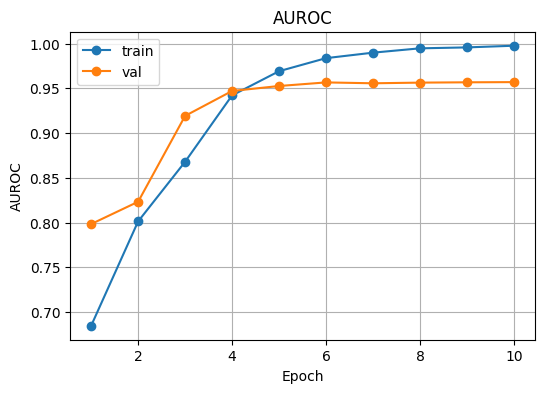

In [29]:
# =========================
# CELL 4: Curves (train vs val)
# =========================

import matplotlib.pyplot as plt

tr_acc = [x[1] for x in history["train"]]
va_acc = [x[1] for x in history["val"]]
tr_loss = [x[0] for x in history["train"]]
va_loss = [x[0] for x in history["val"]]
tr_auc = [x[3] for x in history["train"]]
va_auc = [x[3] for x in history["val"]]
epochs = range(1, len(tr_acc) + 1)

plt.figure(figsize=(6,4))
plt.plot(list(epochs), tr_loss, marker="o", label="train")
plt.plot(list(epochs), va_loss, marker="o", label="val")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(list(epochs), tr_acc, marker="o", label="train")
plt.plot(list(epochs), va_acc, marker="o", label="val")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(list(epochs), tr_auc, marker="o", label="train")
plt.plot(list(epochs), va_auc, marker="o", label="val")
plt.title("AUROC")
plt.xlabel("Epoch")
plt.ylabel("AUROC")
plt.legend()
plt.grid(True)
plt.show()



## 5. Optional: Simple Saliency Map (Captum)

This helps **explain** which pixels most influence the prediction.  
Run after training. Provide a path to a single image.


In [36]:
# =========================
# CELL 7: Load best checkpoint (local first, then Drive fallback)
# No build_model dependency (torchvision EfficientNet-B0 inline)
# =========================
from pathlib import Path
import torch
import torch.nn as nn
from torchvision import models
import shutil

ARTIFACTS_DIR = Path(globals().get("ARTIFACTS_DIR", "artifacts"))
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# Ensure DEVICE is torch.device
if "DEVICE" in globals() and isinstance(DEVICE, str):
    DEVICE = torch.device(DEVICE)
elif "DEVICE" not in globals() or not isinstance(DEVICE, torch.device):
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def _find_drive_ckpt():
    drive_root = Path("/content/drive/MyDrive")
    if not drive_root.exists():
        return None

    base = drive_root / "DeepFakeDetector_runs"
    if not base.exists():
        return None

    best_name = f"best_{USE_MODEL}.pt"

    # 1) If current session has DRIVE_CKPT_DIR from training, use it directly
    if "DRIVE_CKPT_DIR" in globals() and globals().get("DRIVE_CKPT_DIR") is not None:
        p = Path(globals()["DRIVE_CKPT_DIR"]) / best_name
        if p.exists():
            return p

    # 2) Otherwise, pick newest run checkpoint
    candidates = sorted(
        base.glob("*/checkpoints/" + best_name),
        key=lambda p: p.stat().st_mtime,
        reverse=True
    )
    return candidates[0] if candidates else None

def _build_efficientnet_b0(num_classes: int = 2):
    weights = models.EfficientNet_B0_Weights.DEFAULT
    m = models.efficientnet_b0(weights=weights)
    in_features = m.classifier[1].in_features
    m.classifier[1] = nn.Linear(in_features, num_classes)
    return m

def load_best_checkpoint():
    best_name = f"best_{USE_MODEL}.pt"
    local_ckpt = ARTIFACTS_DIR / best_name
    drive_ckpt = _find_drive_ckpt()

    if local_ckpt.exists():
        ckpt_path = local_ckpt
    elif drive_ckpt is not None and drive_ckpt.exists():
        shutil.copy2(drive_ckpt, local_ckpt)
        ckpt_path = local_ckpt
    else:
        raise FileNotFoundError(
            f"No checkpoint found at {local_ckpt}"
            + (f" or {drive_ckpt}" if drive_ckpt is not None else "")
            + ". Train first (the cell that saves best checkpoints)."
        )

    ckpt = torch.load(str(ckpt_path), map_location="cpu")

    model_name = (ckpt.get("model_name") or ckpt.get("arch") or ckpt.get("model") or USE_MODEL or "").lower()

    # This notebook path is EfficientNet-B0 only
    if model_name not in ["efficientnet_b0", "effnet_b0", "efficientnet", ""]:
        print(f"Warning: checkpoint model_name='{model_name}'. Proceeding with EfficientNet-B0 loader anyway.")

    m = _build_efficientnet_b0(num_classes=2).to(DEVICE)
    m.load_state_dict(ckpt["model_state"])
    m.eval()
    return m, ckpt, ckpt_path

model, ckpt, ckpt_path = load_best_checkpoint()
print("Loaded:", ckpt.get("model_name") or ckpt.get("arch") or USE_MODEL)
print("Checkpoint path:", ckpt_path)
print("Label map:", ckpt.get("label_map"))

Loaded: efficientnet_b0
Checkpoint path: artifacts/best_efficientnet_b0.pt
Label map: {'0': 'real', '1': 'fake'}



[nanobanana] n=200 batch_size=64 num_workers=2
Confusion matrix (rows=actual, cols=pred):
            pred_real  pred_fake
actual_real          0         0
actual_fake          4       196
(tn=0, fp=0, fn=4, tp=196)
Accuracy: 0.9800
Recall on fake (sensitivity): 0.98
Specificity: n/a

Classification Report:

              precision    recall  f1-score   support

        real       0.00      0.00      0.00         0
        fake       1.00      0.98      0.99       200

    accuracy                           0.98       200
   macro avg       0.50      0.49      0.49       200
weighted avg       1.00      0.98      0.99       200



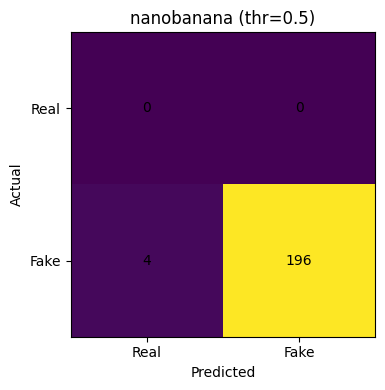

Saved predictions CSV: artifacts/manual_gen/nanobanana/predictions.csv
Saved confusion matrix PNG: artifacts/manual_gen/nanobanana/confusion_matrix.png
Backed up to Drive: /content/drive/MyDrive/DeepFakeDetector_runs/cnn_transfer_20260223_151307/artifacts/manual_gen/nanobanana

[dalle] n=200 batch_size=64 num_workers=2
Confusion matrix (rows=actual, cols=pred):
            pred_real  pred_fake
actual_real          0         0
actual_fake          6       194
(tn=0, fp=0, fn=6, tp=194)
Accuracy: 0.9700
Recall on fake (sensitivity): 0.97
Specificity: n/a

Classification Report:

              precision    recall  f1-score   support

        real       0.00      0.00      0.00         0
        fake       1.00      0.97      0.98       200

    accuracy                           0.97       200
   macro avg       0.50      0.48      0.49       200
weighted avg       1.00      0.97      0.98       200



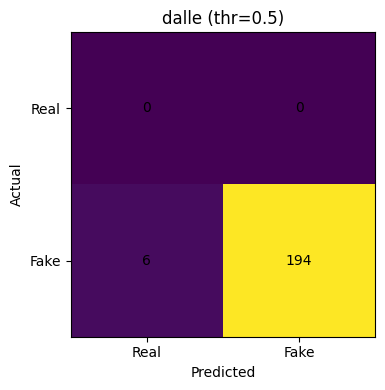

Saved predictions CSV: artifacts/manual_gen/dalle/predictions.csv
Saved confusion matrix PNG: artifacts/manual_gen/dalle/confusion_matrix.png
Backed up to Drive: /content/drive/MyDrive/DeepFakeDetector_runs/cnn_transfer_20260223_151307/artifacts/manual_gen/dalle

[bing] n=54 batch_size=64 num_workers=2
Confusion matrix (rows=actual, cols=pred):
            pred_real  pred_fake
actual_real          0         0
actual_fake          2        52
(tn=0, fp=0, fn=2, tp=52)
Accuracy: 0.9630
Recall on fake (sensitivity): 0.9629629629629629
Specificity: n/a

Classification Report:

              precision    recall  f1-score   support

        real       0.00      0.00      0.00         0
        fake       1.00      0.96      0.98        54

    accuracy                           0.96        54
   macro avg       0.50      0.48      0.49        54
weighted avg       1.00      0.96      0.98        54



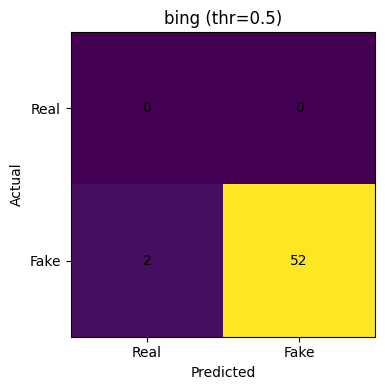

Saved predictions CSV: artifacts/manual_gen/bing/predictions.csv
Saved confusion matrix PNG: artifacts/manual_gen/bing/confusion_matrix.png
Backed up to Drive: /content/drive/MyDrive/DeepFakeDetector_runs/cnn_transfer_20260223_151307/artifacts/manual_gen/bing


In [33]:
# =========================
# MANUAL TESTS - CELL B (prints + displays confusion matrix)
# - prints numeric CM
# - displays CM inline in notebook output
# - saves PNG + saves CSV
# =========================

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

FAKE_IDX = int(globals().get("FAKE_IDX", 1))

# Pick validation transform
val_transform = globals().get("val_tfm") or globals().get("val_tfms")
if val_transform is None:
    raise NameError("No validation transform found. Expected val_tfm or val_tfms.")

# Manual images root
MANUAL_IMAGES_ROOT = Path(globals().get("MANUAL_IMAGES_ROOT", "/content/manual_gen_images/images"))
if not MANUAL_IMAGES_ROOT.exists():
    raise FileNotFoundError(f"Manual images root not found: {MANUAL_IMAGES_ROOT}")

def _is_image(p: Path) -> bool:
    return p.suffix.lower() in [".png", ".jpg", ".jpeg", ".webp"]

class ManualGenFakeDataset(Dataset):
    def __init__(self, img_paths, transform, fake_label=1):
        self.img_paths = list(img_paths)
        self.transform = transform
        self.fake_label = int(fake_label)

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        p = self.img_paths[idx]
        im = Image.open(p).convert("RGB")
        x = self.transform(im)
        y = self.fake_label
        return x, y, str(p)

@torch.inference_mode()
def _collect_probs_and_paths(model, loader, device, fake_idx=1):
    model.eval()
    probs, ys, paths = [], [], []
    for xb, yb, pb in loader:
        xb = xb.to(device, non_blocking=True)
        logits = model(xb)
        prob_fake = torch.softmax(logits, dim=1)[:, int(fake_idx)].detach().cpu().numpy()
        probs.append(prob_fake)
        ys.append(np.asarray(yb))
        paths.extend(list(pb))
    return np.concatenate(probs), np.concatenate(ys), paths

def _save_confusion_matrix_png(cm, out_path: Path, title: str):
    fig = _plot_confusion_matrix(cm, title=title)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close(fig)

def _pretty_print_cm(cm: np.ndarray):
    tn, fp, fn, tp = cm.ravel()
    print("Confusion matrix (rows=actual, cols=pred):")
    print("            pred_real  pred_fake")
    print(f"actual_real     {tn:6d}    {fp:6d}")
    print(f"actual_fake     {fn:6d}    {tp:6d}")
    print(f"(tn={tn}, fp={fp}, fn={fn}, tp={tp})")

def _plot_confusion_matrix(cm: np.ndarray, title: str):
    # Returns a figure; caller can display it and/or save it
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1], ["Real", "Fake"])
    ax.set_yticks([0, 1], ["Real", "Fake"])
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha="center", va="center")
    fig.tight_layout()
    return fig

def test_manual_deepfakes(generator_name: str,
                          threshold: float = 0.5,
                          batch_size: int = 64,
                          num_workers: int = 2,
                          show_cm: bool = True):
    gen_dir = MANUAL_IMAGES_ROOT / generator_name
    if not gen_dir.exists():
        available = [p.name for p in MANUAL_IMAGES_ROOT.iterdir() if p.is_dir()]
        raise FileNotFoundError(
            f"Missing generator folder: {gen_dir}\n"
            f"Available generators under {MANUAL_IMAGES_ROOT}: {available}"
        )

    img_paths = sorted([p for p in gen_dir.rglob("*") if p.is_file() and _is_image(p)])
    if len(img_paths) == 0:
        raise RuntimeError(f"No images found under: {gen_dir}")

    ds = ManualGenFakeDataset(img_paths, transform=val_transform, fake_label=1)
    loader = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=(getattr(DEVICE, "type", "") == "cuda"),
        persistent_workers=(num_workers > 0),
    )

    print(f"\n[{generator_name}] n={len(ds)} batch_size={batch_size} num_workers={num_workers}")
    y_prob, y_true, paths = _collect_probs_and_paths(model, loader, device=DEVICE, fake_idx=FAKE_IDX)

    thr = float(threshold)
    y_pred = (y_prob >= thr).astype(int)

    acc = accuracy_score(y_true, y_pred)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    _pretty_print_cm(cm)

    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else None
    specificity = tn / (tn + fp) if (tn + fp) > 0 else None

    print(f"Accuracy: {acc:.4f}")
    print(f"Recall on fake (sensitivity): {sensitivity if sensitivity is not None else 'n/a'}")
    print(f"Specificity: {specificity if specificity is not None else 'n/a'}")

    print("\nClassification Report:\n")
    print(classification_report(
        y_true, y_pred,
        labels=[0, 1],
        target_names=["real", "fake"],
        zero_division=0
    ))

    # NEW: show confusion matrix inline in cell output
    if show_cm:
        fig = _plot_confusion_matrix(cm, title=f"{generator_name} (thr={thr})")
        plt.show()
        plt.close(fig)

    out_dir = Path(ARTIFACTS_DIR) / "manual_gen" / generator_name
    out_dir.mkdir(parents=True, exist_ok=True)

    pred_csv = out_dir / "predictions.csv"
    df = pd.DataFrame({
        "path": paths,
        "prob_fake": y_prob,
        "y_true": y_true,
        "y_pred": y_pred,
        "threshold": thr,
        "generator": generator_name,
    })
    df.to_csv(pred_csv, index=False)
    print("Saved predictions CSV:", pred_csv)

    cm_png = out_dir / "confusion_matrix.png"
    _save_confusion_matrix_png(cm, cm_png, title=f"{generator_name} (thr={thr})")
    print("Saved confusion matrix PNG:", cm_png)

    if "DRIVE_ARTIFACTS_DIR" in globals() and globals()["DRIVE_ARTIFACTS_DIR"] is not None:
        import shutil
        drive_out = Path(globals()["DRIVE_ARTIFACTS_DIR"]) / "manual_gen" / generator_name
        drive_out.parent.mkdir(parents=True, exist_ok=True)
        if drive_out.exists():
            shutil.rmtree(drive_out)
        shutil.copytree(out_dir, drive_out)
        print("Backed up to Drive:", drive_out)

    return {
        "generator": generator_name,
        "n": int(len(ds)),
        "threshold": thr,
        "acc": float(acc),
        "sensitivity": None if sensitivity is None else float(sensitivity),
        "specificity": None if specificity is None else float(specificity),
        "cm": cm,
        "pred_csv": str(pred_csv),
        "cm_png": str(cm_png),
    }

# Run tests
res_nanobanana = test_manual_deepfakes("nanobanana", threshold=0.5, batch_size=64, num_workers=2, show_cm=True)
res_dalle = test_manual_deepfakes("dalle", threshold=0.5, batch_size=64, num_workers=2, show_cm=True)
res_bing = test_manual_deepfakes("bing", threshold=0.5, batch_size=64, num_workers=2, show_cm=True)

In [35]:
# =========================
# Real-only evaluation on OpenImagesV7 (all labels = 0)
# Reports false positive rate + fake-probability stats
# Also saves top-K most "fake-looking" real images to artifacts/
# =========================
import numpy as np
import torch
from pathlib import Path
import shutil

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(DEVICE)
model.eval()

FAKE_IDX = 1
threshold = float(globals().get("THRESHOLD", 0.5))

# You should already have this from the earlier dataset cell
# openimages_real_loader yields (tensor, 0) for every image
if "openimages_real_loader" not in globals():
    raise NameError("openimages_real_loader not found. Run the OpenImagesV7 real-only loader cell first.")

# Optional: dataset with file paths for saving top-K examples
openimages_paths = None
if "openimages_real_ds" in globals() and hasattr(openimages_real_ds, "paths"):
    openimages_paths = openimages_real_ds.paths

all_probs = []
all_preds = []
all_true = []

# Track indices for top-K highest fake probability
TOP_K = int(globals().get("TOP_K", 25))
top_scores = []
top_indices = []

idx_base = 0

with torch.inference_mode():
    for imgs, labels in openimages_real_loader:
        bs = imgs.size(0)
        imgs = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        logits = model(imgs)
        probs_fake = torch.softmax(logits, dim=1)[:, FAKE_IDX]

        preds = (probs_fake >= threshold).long()

        probs_np = probs_fake.detach().cpu().numpy()
        preds_np = preds.detach().cpu().numpy()
        labels_np = labels.detach().cpu().numpy()

        all_probs.append(probs_np)
        all_preds.append(preds_np)
        all_true.append(labels_np)

        # Update top-K
        for i in range(bs):
            score = float(probs_np[i])
            global_idx = idx_base + i
            if len(top_scores) < TOP_K:
                top_scores.append(score)
                top_indices.append(global_idx)
            else:
                j = int(np.argmin(top_scores))
                if score > top_scores[j]:
                    top_scores[j] = score
                    top_indices[j] = global_idx

        idx_base += bs

probs = np.concatenate(all_probs)
preds = np.concatenate(all_preds)
true  = np.concatenate(all_true)  # should be all zeros

# Metrics (real-only)
fpr = float((preds == 1).mean())
tnr = 1.0 - fpr

print("=== OpenImagesV7 real-only evaluation ===")
print("num images:", len(true))
print("threshold:", threshold)
print("false positive rate (pred fake on real):", round(fpr, 4))
print("true negative rate / specificity:", round(tnr, 4))

print("\nFake probability stats:")
print("mean:", round(float(probs.mean()), 4))
print("median:", round(float(np.median(probs)), 4))
print("p90:", round(float(np.quantile(probs, 0.90)), 4))
print("p95:", round(float(np.quantile(probs, 0.95)), 4))
print("p99:", round(float(np.quantile(probs, 0.99)), 4))
print("max:", round(float(probs.max()), 4))

# Save top-K images (most fake-looking) if we have paths
ARTIFACTS_DIR = Path(globals().get("ARTIFACTS_DIR", "artifacts"))
out_dir = ARTIFACTS_DIR / "openimages_real_topk"
out_dir.mkdir(parents=True, exist_ok=True)

if openimages_paths is not None:
    order = np.argsort(-np.array(top_scores))
    print(f"\nTop-{TOP_K} most fake-looking real images saved to: {out_dir}")
    for rank, pos in enumerate(order, start=1):
        gi = int(top_indices[pos])
        score = float(top_scores[pos])
        src = Path(openimages_paths[gi])
        dst = out_dir / f"{rank:02d}_p{score:.4f}__{src.name}"
        try:
            shutil.copy2(src, dst)
        except Exception as e:
            print("copy failed:", src, "->", dst, "err:", e)
else:
    print("\nNote: could not save top-K images because dataset paths were not found (openimages_real_ds.paths missing).")

print("Checkpoint label_map:", ckpt.get("label_map"))
print("FAKE_IDX used:", 1)

=== OpenImagesV7 real-only evaluation ===
num images: 224
threshold: 0.5
false positive rate (pred fake on real): 0.5357
true negative rate / specificity: 0.4643

Fake probability stats:
mean: 0.5099
median: 0.5516
p90: 0.9466
p95: 0.9607
p99: 0.9788
max: 0.9942

Top-25 most fake-looking real images saved to: artifacts/openimages_real_topk
Checkpoint label_map: {'0': 'real', '1': 'fake'}
FAKE_IDX used: 1


In [43]:
# =========================
# CELL A: Persist OpenImages prob_fake array for later threshold calibration
# Place right after the OpenImages real-only eval cell
# =========================
import numpy as np

# If your eval cell already created `probs` as a numpy array, this keeps it.
if "probs" not in globals():
    raise NameError("Expected `probs` from OpenImages eval cell. Re-run the OpenImages real-only eval cell first.")

openimages_probs = np.array(probs, dtype=np.float32)
globals()["openimages_probs"] = openimages_probs

print("Saved openimages_probs with shape:", openimages_probs.shape)
print("example values:", openimages_probs[:5].tolist())

Saved openimages_probs with shape: (224,)
example values: [0.4485655725002289, 0.5918363332748413, 0.12234754115343094, 0.9718182682991028, 0.7128788232803345]


In [44]:
# =========================
# CELL B: Threshold calibration on OpenImages (real-only)
# Place after Cell A
# =========================
import numpy as np

if "openimages_probs" not in globals():
    raise NameError("openimages_probs not found. Run Cell A first.")

p = openimages_probs

targets = [0.20, 0.10, 0.05, 0.01]
print("Target FPR -> threshold -> actual FPR")
for target in targets:
    thr = float(np.quantile(p, 1.0 - target))
    actual = float((p >= thr).mean())
    print(f"{target:0.2f} -> {thr:.4f} -> {actual:.4f}")

# Pick one default recommendation (5% by default)
TARGET_FPR = float(globals().get("TARGET_FPR", 0.05))
thr_reco = float(np.quantile(p, 1.0 - TARGET_FPR))
globals()["OPENIMAGES_THRESHOLD_RECOMMENDED"] = thr_reco

print("\nRecommended threshold for target FPR =", TARGET_FPR, "is", round(thr_reco, 4))

Target FPR -> threshold -> actual FPR
0.20 -> 0.8900 -> 0.2009
0.10 -> 0.9466 -> 0.1027
0.05 -> 0.9607 -> 0.0536
0.01 -> 0.9788 -> 0.0134

Recommended threshold for target FPR = 0.05 is 0.9607



## 6. Inference Helper


In [ ]:
# =========================
# CELL 8: Cross-dataset eval for Issue #38
# - pick threshold on OpenFake val (max F1)
# - apply same threshold to WildFake and DRAGON
# - save metrics CSV, confusion matrices, ROC curves
# - backup everything to Drive
# =========================
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_curve, auc

CROSS_DIR = ARTIFACTS_DIR / "cross_dataset"
CROSS_DIR.mkdir(parents=True, exist_ok=True)

@torch.inference_mode()
def collect_probs(model, loader):
    model.eval()
    probs_all, y_all = [], []
    for imgs, y in loader:
        imgs = imgs.to(DEVICE, non_blocking=False)
        logits = model(imgs)
        probs_fake = torch.softmax(logits, dim=1)[:, FAKE_IDX]
        probs_all.append(probs_fake.detach().cpu().numpy())
        y_all.append(y.numpy())
    return np.concatenate(probs_all), np.concatenate(y_all)

def pick_threshold_on_val(y_prob, y_true):
    thresholds = np.linspace(0.0, 1.0, 501)
    best_t, best_score = 0.5, -1.0
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        score = f1_score(y_true, y_pred, zero_division=0)
        if score > best_score:
            best_score = score
            best_t = t
    return float(best_t), float(best_score)

def eval_with_threshold(y_prob, y_true, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    try:
        auroc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auroc = float("nan")
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    return float(acc), float(f1), float(auroc), cm

def save_confusion_matrix(cm, title, out_path):
    plt.figure(figsize=(4.5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks([0, 1], ["real(0)", "fake(1)"])
    plt.yticks([0, 1], ["real(0)", "fake(1)"])
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center")
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close()

def save_roc_curve(y_prob, y_true, title, out_path):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(title)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close()

# Dataset paths
DATASETS_ROOT = Path("/content/drive/MyDrive/datasets")
OPENFAKE_VAL_DIR = Path(val_dir)
WILDFAKE_VAL_DIR = DATASETS_ROOT / "wildfake_2k_split" / "test"
DRAGON_VAL_DIR   = DATASETS_ROOT / "DRAGON" / "test"

for d in [WILDFAKE_VAL_DIR, DRAGON_VAL_DIR]:
    assert d.exists(), f"Missing folder: {d}"
    assert (d / "real").exists() and (d / "fake").exists(), f"{d} must contain real/ and fake/"

# Choose threshold on OpenFake val
a_val_ds = imagefolder_fixed_labels(OPENFAKE_VAL_DIR, transform=val_tfms)
a_val_loader = DataLoader(a_val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=False)

y_prob_A, y_raw_A = collect_probs(model, a_val_loader)
y_true_A = (y_raw_A == FAKE_IDX).astype(int)

best_t, best_f1 = pick_threshold_on_val(y_prob_A, y_true_A)
print(f"Chosen threshold on OpenFake val (max F1): t={best_t:.3f} (F1={best_f1:.3f})")

datasets_to_eval = [
    ("A(OpenFake)", OPENFAKE_VAL_DIR),
    ("B(wildfake_2k_split)", WILDFAKE_VAL_DIR),
    ("C(DRAGON)", DRAGON_VAL_DIR),
]

rows = []
for tag, split_path in datasets_to_eval:
    ds = imagefolder_fixed_labels(split_path, transform=val_tfms)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=False)

    y_prob, y_raw = collect_probs(model, loader)
    y_true = (y_raw == FAKE_IDX).astype(int)

    acc, f1, auroc, cm = eval_with_threshold(y_prob, y_true, threshold=best_t)

    rows.append({
        "dataset": tag,
        "n": len(ds),
        "threshold": best_t,
        "acc": acc,
        "f1": f1,
        "auroc": None if np.isnan(auroc) else auroc,
        "tn": int(cm[0, 0]),
        "fp": int(cm[0, 1]),
        "fn": int(cm[1, 0]),
        "tp": int(cm[1, 1]),
    })

    cm_path = CROSS_DIR / f"{tag}_confusion_matrix.png"
    roc_path = CROSS_DIR / f"{tag}_roc.png"
    save_confusion_matrix(cm, f"{tag} Confusion Matrix (t={best_t:.3f})", cm_path)
    save_roc_curve(y_prob, y_true, f"{tag} ROC Curve", roc_path)

metrics_df = pd.DataFrame(rows)
display(metrics_df)

metrics_csv = CROSS_DIR / "cross_dataset_metrics.csv"
metrics_df.to_csv(metrics_csv, index=False)

note_path = CROSS_DIR / "threshold_note.txt"
note_path.write_text(
    f"Threshold chosen on OpenFake validation by maximizing F1: t={best_t:.3f} (F1={best_f1:.3f}).\n"
    "Same threshold applied unchanged to wildfake_2k_split and DRAGON.\n"
    "Label mapping enforced as 0=real and 1=fake.\n"
)

print("Saved:", metrics_csv)
print("Saved:", note_path)
print("Saved plots in:", CROSS_DIR)

# # Backup whole cross_dataset folder to Drive
# DRIVE_CROSS_DIR = DRIVE_ARTIFACTS_DIR / "cross_dataset"
# if DRIVE_CROSS_DIR.exists():
#     shutil.rmtree(DRIVE_CROSS_DIR)
# shutil.copytree(CROSS_DIR, DRIVE_CROSS_DIR)
# print("Backed up cross-dataset artifacts to Drive:", DRIVE_CROSS_DIR)



## 7. Record Results (Fill After Training)

- **Backbone:** EfficientNet-B0 or ResNet-50  
- **Freeze > Unfreeze epoch:** e.g., 1–2 epochs frozen, unfreeze at 3  
- **Val Accuracy:** …  
- **Val F1:** …  
- **Val AUROC:** …  
- **Observations:** … (e.g., overfitting signs, which backbone worked better, any class imbalance tweaks)

> Tip: If your dataset is imbalanced, consider using `WeightedRandomSampler` or class weights in `CrossEntropyLoss`.


In [ ]:
# =========================
# CELL 9: Export artifacts for Issue #42 (and back up to Drive)
# Exports:
# - model.pth
# - config.json (includes threshold)
# - preprocess.json
# - label_map.json
# - README.md
# =========================
import os, json
from datetime import datetime

EXPORT_DIR = Path("export/cnn-transfer")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Save weights (state_dict only)
torch.save(model.state_dict(), EXPORT_DIR / "model.pth")

preprocess = {
    "input_size": [IM_SIZE, IM_SIZE],
    "resize": {"enabled": True, "size": [IM_SIZE, IM_SIZE]},
    "center_crop": {"enabled": False},
    "normalize": {"mean": [0.485, 0.456, 0.406], "std": [0.229, 0.224, 0.225]},
    "notes": "Resize to IM_SIZE x IM_SIZE then normalize with ImageNet mean/std."
}

label_map = {"0": "real", "1": "fake"}

config = {
    "name": "cnn-transfer",
    "framework": "pytorch",
    "arch": USE_MODEL,
    "num_classes": 2,
    "threshold": float(best_t) if "best_t" in globals() else 0.50,
    "labels": label_map,
    "exported_at_utc": datetime.utcnow().isoformat() + "Z",
    "notes": "CNN transfer baseline for deepfake detection. prob_fake = softmax(logits)[fake]."
}

readme = f"""---
license: apache-2.0
tags:
  - image-classification
  - deepfake-detection
  - pytorch
---

# CNN Transfer (DeepFakeDetector)

Binary image classifier for deepfake or AI-generated image detection.

## Label convention (fixed)
- 0 = real
- 1 = fake

## Preprocessing
- Resize to {IM_SIZE}x{IM_SIZE}
- Normalize with ImageNet mean/std

## Output
- prob_fake in [0, 1] computed as softmax(logits)[fake]
- decision threshold: {config["threshold"]:.3f}
"""

with open(EXPORT_DIR / "preprocess.json", "w") as f:
    json.dump(preprocess, f, indent=2)
with open(EXPORT_DIR / "label_map.json", "w") as f:
    json.dump(label_map, f, indent=2)
with open(EXPORT_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=2)
with open(EXPORT_DIR / "README.md", "w") as f:
    f.write(readme)

print("Exported files:", sorted([p.name for p in EXPORT_DIR.iterdir()]))

# Backup export folder to Drive
DRIVE_EXPORT_DIR = DRIVE_RUN_DIR / "export" / "cnn-transfer"
if DRIVE_EXPORT_DIR.exists():
    shutil.rmtree(DRIVE_EXPORT_DIR)
shutil.copytree(EXPORT_DIR, DRIVE_EXPORT_DIR)
print("Backed up export folder to Drive:", DRIVE_EXPORT_DIR)



## 8. (Optional) Write a `requirements.txt`

Run this cell once to generate a minimal `requirements.txt` alongside artifacts.


In [ ]:
# =========================
# CELL 10: Install Hugging Face hub client (safe to run)
# =========================
%pip -q install huggingface_hub


In [ ]:
import os, getpass

os.environ["HF_TOKEN_WRITE"] = getpass.getpass("Paste your Hugging Face WRITE token (input hidden): ")
print("HF_TOKEN_WRITE set for this runtime:", "yes" if os.environ.get("HF_TOKEN_WRITE") else "no")


In [ ]:
# =========================
# CELL 11: Upload export folder to Hugging Face (Issue #42)
# Requires env var: HF_TOKEN_WRITE
# =========================
import os
from huggingface_hub import HfApi

REPO_ID = "DeepFakeDetector/cnn-transfer"
HF_TOKEN = os.environ.get("HF_TOKEN_WRITE")
assert HF_TOKEN, "Missing HF_TOKEN_WRITE. Set it in your environment (do not commit it)."

api = HfApi(token=HF_TOKEN)
api.create_repo(repo_id=REPO_ID, repo_type="model", exist_ok=True)

api.upload_folder(
    folder_path=str(EXPORT_DIR),
    repo_id=REPO_ID,
    repo_type="model",
    commit_message="Upload CNN transfer artifacts (model + preprocess + config)"
)

print(f"Uploaded to https://huggingface.co/{REPO_ID}")


In [ ]:
import os
from huggingface_hub import whoami

tok = os.environ.get("HF_TOKEN_WRITE")
print("HF_TOKEN_WRITE set:", bool(tok))
print("Token starts with:", tok[:8] + "..." if tok else None)

print("whoami:", whoami(token=tok))


In [38]:
# =========================
# CELL 12: Reload test (download snapshot -> load -> 1 inference)
# Deterministic + token-safe + NO build_model dependency
# Saves a note to Drive if DRIVE_RUN_DIR exists
# =========================

import os, json
from pathlib import Path
import torch
import torch.nn as nn
from huggingface_hub import snapshot_download
from PIL import Image
from torchvision import models, transforms

REPO_ID = "DeepFakeDetector/cnn-transfer"

# 1) Download snapshot with auth (works for private + avoids 401)
HF_TOKEN = os.environ.get("HF_TOKEN_WRITE") or os.environ.get("HF_TOKEN")
assert HF_TOKEN, "Missing HF token in env. Set HF_TOKEN_WRITE before running reload test."

local_repo = Path(snapshot_download(
    repo_id=REPO_ID,
    repo_type="model",
    token=HF_TOKEN
))
print("Downloaded snapshot to:", local_repo)

# 2) Load config + preprocess + label map
with open(local_repo / "config.json", "r") as f:
    cfg = json.load(f)

with open(local_repo / "preprocess.json", "r") as f:
    pp = json.load(f)

with open(local_repo / "label_map.json", "r") as f:
    label_map = json.load(f)

# Enforce label convention: 0 real, 1 fake
assert str(label_map.get("0")).lower() == "real" and str(label_map.get("1")).lower() == "fake", f"Bad label_map.json: {label_map}"

# 3) Rebuild model exactly (no build_model)
arch = str(cfg.get("arch", "efficientnet_b0")).lower()

def build_from_arch(arch_name: str, num_classes: int = 2):
    if arch_name in ["efficientnet_b0", "effnet_b0", "efficientnet"]:
        m = models.efficientnet_b0(weights=None)  # weights None because we load state_dict
        in_features = m.classifier[1].in_features
        m.classifier[1] = nn.Linear(in_features, num_classes)
        return m
    raise ValueError(f"Unsupported arch '{arch_name}' in reload test. Add mapping here.")

reload_model = build_from_arch(arch, num_classes=2).to("cpu")

state = torch.load(local_repo / "model.pth", map_location="cpu")
reload_model.load_state_dict(state)
reload_model.eval()

# 4) Pick one sample image
sample_path = None

try:
    if "val_dir" in globals():
        for cls in ["real", "fake"]:
            cand_dir = Path(val_dir) / cls
            if cand_dir.exists():
                imgs = sorted([p for p in cand_dir.glob("*") if p.suffix.lower() in [".jpg",".jpeg",".png",".webp"]])
                if imgs:
                    sample_path = str(imgs[0])
                    break
except Exception:
    pass

if sample_path is None:
    for base in [Path("datasets"), Path("/content/datasets"), Path("/content/drive/MyDrive/datasets")]:
        if base.exists():
            imgs = list(base.rglob("*.jpg")) + list(base.rglob("*.png")) + list(base.rglob("*.jpeg")) + list(base.rglob("*.webp"))
            if imgs:
                sample_path = str(sorted(imgs)[0])
                break

assert sample_path is not None, "Could not find any image file for inference test."

# 5) Preprocess
# Prefer using your existing val_tfms/val_tfm if present, otherwise use preprocess.json
img = Image.open(sample_path).convert("RGB")

x = None
if "val_tfms" in globals():
    try:
        x = val_tfms(img).unsqueeze(0)
    except Exception:
        x = None
if x is None and "val_tfm" in globals():
    try:
        x = val_tfm(img).unsqueeze(0)
    except Exception:
        x = None

if x is None:
    mean = pp["normalize"]["mean"]
    std  = pp["normalize"]["std"]
    size = int(pp["input_size"])
    tfm = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])
    x = tfm(img).unsqueeze(0)

x = x.to("cpu")

# 6) Inference
with torch.no_grad():
    logits = reload_model(x)
    prob_fake = torch.softmax(logits, dim=1)[0, 1].item()

thr = float(cfg.get("threshold", 0.5))
pred = 1 if prob_fake >= thr else 0

print("Sample:", sample_path)
print("prob_fake:", prob_fake)
print("threshold:", thr)
print("pred:", pred, "(0=real,1=fake)")
print("Reload test OK.")

# 7) Save note in Drive if available
try:
    if "DRIVE_RUN_DIR" in globals():
        Path(DRIVE_RUN_DIR).mkdir(parents=True, exist_ok=True)
        (Path(DRIVE_RUN_DIR) / "hf_reload_note.txt").write_text(
            f"snapshot_download path: {local_repo}\n"
            f"arch: {arch}\n"
            f"sample: {sample_path}\n"
            f"prob_fake: {prob_fake}\n"
            f"threshold: {thr}\n"
            f"pred: {pred}\n"
        )
        print("Saved reload note to Drive:", Path(DRIVE_RUN_DIR) / "hf_reload_note.txt")
except Exception as e:
    print("Drive note save skipped:", e)

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Downloaded snapshot to: /root/.cache/huggingface/hub/models--DeepFakeDetector--cnn-transfer/snapshots/2296094e1a97b8ab67311eccc386cc3f85cbde64
Sample: /content/datasets/OpenImagesV7/all_real/train_0000000.jpg
prob_fake: 0.6831622123718262
threshold: 0.452
pred: 1 (0=real,1=fake)
Reload test OK.
Saved reload note to Drive: /content/drive/MyDrive/DeepFakeDetector_runs/cnn_transfer_20260223_151307/hf_reload_note.txt


In [42]:
from pathlib import Path
import numpy as np
import torch
from PIL import Image
from torchvision import transforms

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval().to(DEVICE)

# Use the same input size and normalization as your reload test pipeline
IM_SIZE = 224
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]
tfm = transforms.Compose([
    transforms.Resize((IM_SIZE, IM_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

def collect_probs(folder: str, n=100):
    folder = Path(folder)
    paths = sorted([p for p in folder.rglob("*") if p.suffix.lower() in [".jpg",".jpeg",".png",".webp"]])[:n]
    probs = []
    with torch.inference_mode():
        for p in paths:
            img = Image.open(p).convert("RGB")
            x = tfm(img).unsqueeze(0).to(DEVICE)
            prob_fake = torch.softmax(model(x), dim=1)[0, 1].item()
            probs.append(prob_fake)
    probs = np.array(probs, dtype=np.float32)
    return probs

# TODO: update these paths to a dataset you have
REAL_DIR = "/content/dataset_local_OpenFake/test/real"
FAKE_DIR = "/content/dataset_local_wildfake_2k_split/test/fake"

real_probs = collect_probs(REAL_DIR, n=100)
fake_probs = collect_probs(FAKE_DIR, n=100)

thr = 0.452  # from cfg threshold
real_fpr = float((real_probs >= thr).mean())
fake_tpr = float((fake_probs >= thr).mean())

print("threshold:", thr)
print("real median prob_fake:", float(np.median(real_probs)), "FPR on real:", real_fpr)
print("fake median prob_fake:", float(np.median(fake_probs)), "TPR on fake:", fake_tpr)

threshold: 0.452
real median prob_fake: 0.07866908609867096 FPR on real: 0.18
fake median prob_fake: 0.8897912502288818 TPR on fake: 0.88


In [45]:
# =========================
# CELL C: Compare default threshold vs calibrated OpenImages threshold
# Place after you have real_probs and fake_probs from the real/fake sanity test
# =========================
import numpy as np

if "real_probs" not in globals() or "fake_probs" not in globals():
    raise NameError("real_probs/fake_probs not found. Run your real-vs-fake sanity test cell first.")

default_thr = float(globals().get("DEFAULT_THRESHOLD", 0.452))  # from your HF config.json
reco_thr = float(globals().get("OPENIMAGES_THRESHOLD_RECOMMENDED", default_thr))

def _rate(probs, thr):
    probs = np.array(probs, dtype=np.float32)
    return float((probs >= thr).mean())

print("=== Threshold comparison ===")
print("default_thr:", default_thr)
print("reco_thr (OpenImages calibrated):", round(reco_thr, 4))

print("\nIn-distribution real/fake rates")
print("FPR on real at default:", round(_rate(real_probs, default_thr), 4))
print("TPR on fake at default:", round(_rate(fake_probs, default_thr), 4))

print("FPR on real at reco  :", round(_rate(real_probs, reco_thr), 4))
print("TPR on fake at reco  :", round(_rate(fake_probs, reco_thr), 4))

print("\nOpenImages real-only FPR at reco threshold")
if "openimages_probs" in globals():
    print("FPR on OpenImages at reco:", round(_rate(openimages_probs, reco_thr), 4))
else:
    print("openimages_probs missing, run Cell A first.")

=== Threshold comparison ===
default_thr: 0.452
reco_thr (OpenImages calibrated): 0.9607

In-distribution real/fake rates
FPR on real at default: 0.18
TPR on fake at default: 0.88
FPR on real at reco  : 0.0
TPR on fake at reco  : 0.24

OpenImages real-only FPR at reco threshold
FPR on OpenImages at reco: 0.0536


In [ ]:
# =========================
# CELL 13: Final status summary
# =========================
print("Local best checkpoint:", best_path if best_path.exists() else "missing")
print("Drive run folder:", DRIVE_RUN_DIR)

print("Drive checkpoints:", [p.name for p in DRIVE_CKPT_DIR.glob("*.pt")])
print("Drive artifacts:", [p.name for p in DRIVE_ARTIFACTS_DIR.glob("*") if p.is_file()])
print("Drive export:", DRIVE_EXPORT_DIR if "DRIVE_EXPORT_DIR" in globals() else "not created yet")
print("If upload succeeded, HF repo should contain: model.pth, config.json, preprocess.json, label_map.json, README.md")


In [ ]:
# =========================
# ISSUE #38: Cross-dataset generalization eval (A=OpenFake, B=WildFake, C=DRAGON)
# Outputs (saved locally + backed up to Drive):
# - artifacts/cross_dataset_metrics.csv
# - artifacts/cross_dataset/ (confusion matrices + ROC curves for A/B/C)
# - artifacts/threshold_note.txt
#
# Label convention enforced: 0=real, 1=fake
# Threshold: chosen on Dataset A validation, applied unchanged to B and C
# =========================

import os, json, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from torchvision import datasets

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, auc
)

# --------- REQUIRED: these should already exist from earlier cells ----------
# model (loaded best), val_tfms, DEVICE, BATCH_SIZE, NUM_WORKERS
# ARTIFACTS_DIR, DRIVE_ARTIFACTS_DIR, FAKE_IDX, REAL_IDX
# If you didn't run the "load best" cell, run it before this.

# --------- Helper: enforce label map 0=real, 1=fake even if folder order differs ----------
def imagefolder_fixed_labels(root_dir: Path, transform):
    ds = datasets.ImageFolder(str(root_dir), transform=transform)

    # ds.class_to_idx could be {'fake':0,'real':1} or {'real':0,'fake':1}
    # We remap targets so that real->0, fake->1 always.
    assert "real" in ds.class_to_idx and "fake" in ds.class_to_idx, \
        f"Expected subfolders real/ and fake/ in {root_dir}"

    old_real = ds.class_to_idx["real"]
    old_fake = ds.class_to_idx["fake"]

    old_to_new = {old_real: 0, old_fake: 1}  # new: real=0, fake=1

    # Update targets + samples
    ds.targets = [old_to_new[y] for y in ds.targets]
    ds.samples = [(p, old_to_new[y]) for (p, y) in ds.samples]

    ds.classes = ["real", "fake"]
    ds.class_to_idx = {"real": 0, "fake": 1}
    return ds

@torch.inference_mode()
def collect_probs(model, loader):
    model.eval()
    probs_all, y_all = [], []
    for imgs, y in loader:
        imgs = imgs.to(DEVICE, non_blocking=False)
        logits = model(imgs)
        # IMPORTANT: prob_fake = P(class=1) after enforcing 0=real,1=fake
        probs_fake = torch.softmax(logits, dim=1)[:, 1]
        probs_all.append(probs_fake.detach().cpu().numpy())
        y_all.append(np.array(y))
    return np.concatenate(probs_all), np.concatenate(y_all)

def pick_threshold_on_val(y_prob, y_true):
    # choose threshold that maximizes F1 on validation
    thresholds = np.linspace(0.0, 1.0, 501)
    best_t, best_f1 = 0.5, -1.0
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    return float(best_t), float(best_f1)

def eval_with_threshold(y_prob, y_true, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, zero_division=0)
    try:
        auroc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auroc = float("nan")
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])  # [[tn,fp],[fn,tp]]
    return float(acc), float(f1), float(auroc), cm

def save_confusion_matrix(cm, title, out_path):
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.figure(figsize=(4.6, 4.0))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks([0, 1], ["real(0)", "fake(1)"])
    plt.yticks([0, 1], ["real(0)", "fake(1)"])
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(int(v)), ha="center", va="center")
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close()

def save_roc_curve(y_prob, y_true, title, out_path):
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(5.2, 4.0))
    plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(title)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close()

# --------- Paths (edit if your folders differ) ----------
# A: OpenFake uses your notebook's val_dir already
DATASET_A_VAL_DIR = Path(val_dir)

# B/C: set these based on your Drive structure
# Your screenshot showed: drive/MyDrive/datasets/OpenFake, wildfake_2k_split, DRAGON
DRIVE_DATASETS = Path("/content/drive/MyDrive/datasets")

DATASET_B_VAL_DIR = DRIVE_DATASETS / "wildfake_2k_split" / "test"
DATASET_C_VAL_DIR = DRIVE_DATASETS / "DRAGON" / "test"

# If your splits are named differently, change "test" to "val" or whatever your folders use.
for d in [DATASET_A_VAL_DIR, DATASET_B_VAL_DIR, DATASET_C_VAL_DIR]:
    assert d.exists(), f"Missing folder: {d}"
    assert (d / "real").exists() and (d / "fake").exists(), f"{d} must contain real/ and fake/"

# --------- Local + Drive output dirs ----------
CROSS_DIR = ARTIFACTS_DIR / "cross_dataset"
CROSS_DIR.mkdir(parents=True, exist_ok=True)

DRIVE_CROSS_DIR = DRIVE_ARTIFACTS_DIR / "cross_dataset"
DRIVE_CROSS_DIR.mkdir(parents=True, exist_ok=True)

# --------- Build loaders ----------
def make_loader(root_dir: Path):
    ds = imagefolder_fixed_labels(root_dir, transform=val_tfms)
    loader = DataLoader(
        ds, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=False
    )
    return ds, loader

a_ds, a_loader = make_loader(DATASET_A_VAL_DIR)
b_ds, b_loader = make_loader(DATASET_B_VAL_DIR)
c_ds, c_loader = make_loader(DATASET_C_VAL_DIR)

print("A(OpenFake) n=", len(a_ds))
print("B(WildFake) n=", len(b_ds))
print("C(DRAGON)   n=", len(c_ds))
print("Label map enforced:", a_ds.class_to_idx)

# --------- Collect probs + choose threshold on A only ----------
y_prob_A, y_true_A = collect_probs(model, a_loader)
best_t, best_f1 = pick_threshold_on_val(y_prob_A, y_true_A)

print(f"Chosen threshold on A(OpenFake) val by max F1: t={best_t:.3f} (F1={best_f1:.3f})")

# --------- Evaluate A/B/C using same threshold ----------
datasets_to_eval = [
    ("A_OpenFake", a_ds, a_loader),
    ("B_WildFake", b_ds, b_loader),
    ("C_DRAGON",   c_ds, c_loader),
]

rows = []
for tag, ds, loader in datasets_to_eval:
    y_prob, y_true = collect_probs(model, loader)
    acc, f1, auroc, cm = eval_with_threshold(y_prob, y_true, threshold=best_t)

    rows.append({
        "dataset": tag,
        "n": len(ds),
        "threshold": best_t,
        "acc": acc,
        "f1": f1,
        "auroc": None if np.isnan(auroc) else auroc,
        "tn": int(cm[0, 0]),
        "fp": int(cm[0, 1]),
        "fn": int(cm[1, 0]),
        "tp": int(cm[1, 1]),
    })

    save_confusion_matrix(cm, f"{tag} Confusion Matrix (t={best_t:.3f})", CROSS_DIR / f"{tag}_confusion_matrix.png")
    save_roc_curve(y_prob, y_true, f"{tag} ROC Curve", CROSS_DIR / f"{tag}_roc.png")

metrics_df = pd.DataFrame(rows)
display(metrics_df)

# --------- Save metrics + note ----------
metrics_csv = ARTIFACTS_DIR / "cross_dataset_metrics.csv"
metrics_df.to_csv(metrics_csv, index=False)

note_path = ARTIFACTS_DIR / "threshold_note.txt"
note_path.write_text(
    f"Threshold chosen on A(OpenFake) validation by maximizing F1: t={best_t:.3f} (F1={best_f1:.3f}).\n"
    f"Applied unchanged to B(WildFake) and C(DRAGON).\n"
    f"Label mapping enforced for all datasets: 0=real, 1=fake.\n"
)

print("Saved:", metrics_csv)
print("Saved:", note_path)
print("Saved plots in:", CROSS_DIR)

# --------- Backup to Drive (create dirs then copy) ----------
# Copy flat files
shutil.copy2(metrics_csv, DRIVE_ARTIFACTS_DIR / metrics_csv.name)
shutil.copy2(note_path, DRIVE_ARTIFACTS_DIR / note_path.name)

# Copy the whole cross_dataset folder (overwrite)
if DRIVE_CROSS_DIR.exists():
    shutil.rmtree(DRIVE_CROSS_DIR)
shutil.copytree(CROSS_DIR, DRIVE_CROSS_DIR)

print("Backed up to Drive:")
print("- metrics:", DRIVE_ARTIFACTS_DIR / metrics_csv.name)
print("- note:", DRIVE_ARTIFACTS_DIR / note_path.name)
print("- folder:", DRIVE_CROSS_DIR)
